In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pillow_lab_rotation import lds
from pillow_lab_rotation.simulate import LDSSim
from importlib import reload
inv = np.linalg.inv
plt.style.use('../JS.mplstyle')

In [2]:
from pillow_lab_rotation.tools import vec

m = 10
n = 20
k = 5
W = np.random.randn(m, k)
H = np.random.randn(k, n)

In [3]:
true = np.linalg.trace(H.T @ W.T @ W @ H)
guess = vec(H).T @ np.kron(np.eye(n), W.T @ W) @ vec(H)

In [4]:
true, guess

(np.float64(1002.3897485202506), np.float64(1002.3897485202508))

In [5]:
def generate_outreach_data(n_trials: int, T: int, noise: float=0.05):
    thetas = np.deg2rad(np.linspace(0, 360, 9))[:-1]
    r = np.linspace(0, 1, T)
    X = np.zeros((n_trials, T, 2, 1))
    
    for n in range(n_trials):
        theta = np.random.choice(thetas)
        x = r * np.cos(theta) + np.random.normal(0, noise, T)
        y = r * np.sin(theta) + np.random.normal(0, noise, T)
        X[n] = np.array([x, y]).T[..., None]
    
    return X

# Test to see if arbitrary invertible $H$ changes log-likelihood

It shouldn't!

In [9]:
X = generate_outreach_data(10, 25)

In [ ]:
xdim = 2
ydim = 2

model = lds.LinearDynamicalSystem(xdim=2, ydim=2)

In [ ]:
model.fit(X)

In [6]:
model.predict(X)[-1] / (50000 * 25) - model.LL

np.float64(0.0)

# Change parameters

In [7]:
H = np.random.standard_normal((ydim, ydim))
H_inv = np.linalg.inv(H)

model.A = H @ model.A @ H_inv
model.C = model.C @ H_inv
model.Q = H @ model.Q @ H.T
model.Q0 = H @ model.Q0 @ H.T
model.mu0 = H @ model.mu0

# Look at log-likelihood again

In [8]:
transformed_ll = model.predict(X)[-1] / (50000 * 25)
print(f'Transformed model LL: {transformed_ll}')
print(f'Original model LL: {model.LL}')
print(f'Delta: {transformed_ll - model.LL}')

Transformed model LL: 2.632922834194616
Original model LL: 2.6329228341946163
Delta: -4.440892098500626e-16


### Now let's see if the MSE between the fitted parameters and the ground-truth parameters also goes down monotonically with the amount of data. The CTDS model inherits most of its functionalitry from the LDS model, so this should diagnose if it is something to do with the 

In [9]:
from pillow_lab_rotation.plotting import plot_ctds_matrices

In [19]:
reload(lds)

<module 'pillow_lab_rotation.lds' from '/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/src/pillow_lab_rotation/lds.py'>

In [20]:
xdim, ydim = 5, 10
simulation = LDSSim(xdim, ydim)
np.random.seed(42)
simulation.create_params()
trial_list = [50, 100, 200, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000]
X_all, Y_all = simulation.simulate(100, trial_list[-1])

A_loss = []
C_loss = []
Q_loss = []
R_loss = []

A_true, C_true, Q_true, Q0_true, mu0_true, R_true = simulation.get_params()
np.random.seed(0)
lds_model = lds.LinearDynamicalSystem(xdim, ydim)

for n_trials in trial_list:
    print(f'Fitting with {n_trials}')
    lds_model.C = C_true.copy()
    lds_model.A = A_true.copy()
    lds_model.Q = Q_true.copy()
    lds_model.R = R_true.copy()
    lds_model.Q0 = Q0_true.copy()
    lds_model.mu0 = mu0_true.copy()

    Y = Y_all[:n_trials]
    lds_model.fit(Y)

    C_prime = lds_model.C
    H = np.linalg.inv(C_prime.T @ C_prime) @ C_prime.T @ C_true
    H_inv = np.linalg.inv(H)

    A_rec = H_inv @ lds_model.A @ H
    C_rec = lds_model.C @ H
    Q_rec = H_inv @ lds_model.Q @ H_inv.T

    A_loss.append(np.mean((A_rec - A_true)**2))
    C_loss.append(np.mean((C_rec - C_true)**2))
    Q_loss.append(np.mean((Q_rec - Q_true)**2))
    R_loss.append(np.mean((lds_model.R - R_true)**2))

Fitting with 50
Fitting with 100
Fitting with 200
Fitting with 500
Fitting with 1000
Fitting with 1500
Fitting with 2000
Fitting with 5000
Fitting with 10000
Fitting with 20000
Fitting with 40000


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (11,) and (10,)

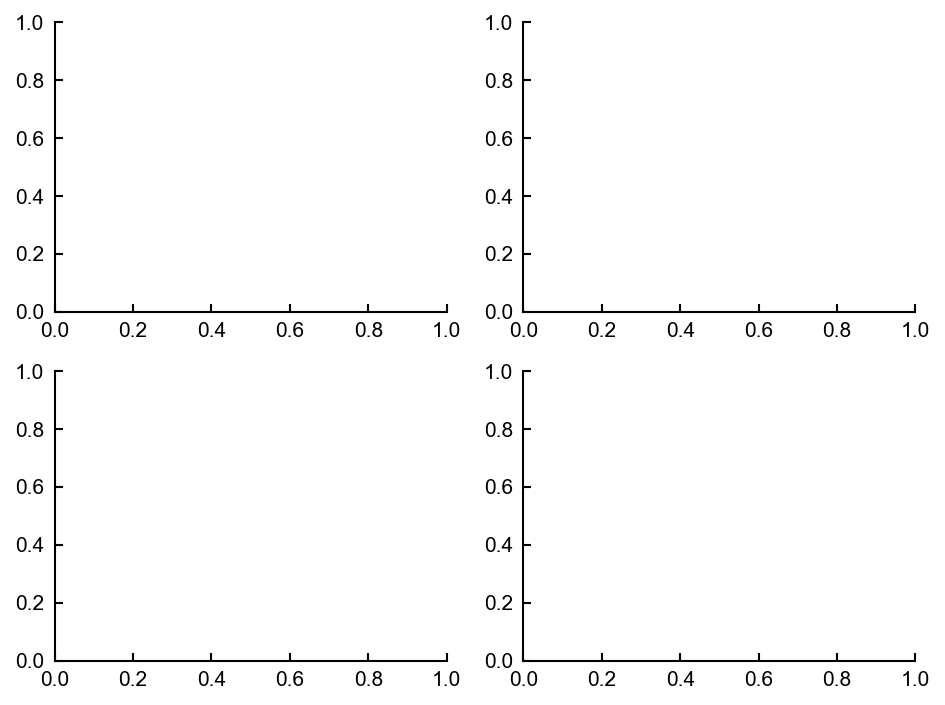

In [ ]:
fig, axes = plt.subplots(2, 2)
titles = ['$A$ MSE (aligned)', '$C$ MSE (aligned)', '$Q$ MSE (aligned)', '$R$ MSE']
losses = [A_loss, C_loss, Q_loss, R_loss]

for ax, title, loss in zip(axes.flat, titles, losses):
    ax.plot(50 * np.array(trial_list), loss)
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('time points')

fig.suptitle('Initializing at true parameter')
fig.tight_layout()

In [18]:
np.diff(R_loss)

array([-3.33286991e-02,  1.30544526e-03, -3.41465774e-03, -4.23207012e-04,
       -5.46830072e-04, -2.54684984e-04, -1.52297236e-04, -1.18650602e-04,
       -2.30267855e-05, -6.16404606e-06])